# Theory demo

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numba import njit, prange

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7.5,
})

SEED = 2026
N_STREAMS = 300
T_MAX = 50_000
N_CANDIDATES = 101
PLOT_START = 1_500
KAPPA = 1.0
DELTA = 0.80

TIMES = np.arange(1, T_MAX + 1)
CANDIDATES = np.linspace(0.0, 1.0, N_CANDIDATES)

SYNTHETIC_DIR = Path.cwd()
if not (SYNTHETIC_DIR / "plot_demo.py").exists():
    SYNTHETIC_DIR /= "synthetic"
DATA_DIR = SYNTHETIC_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
@dataclass(frozen=True)
class FiniteLaw:
    support: tuple
    probabilities: tuple

    def mean(self):
        x = np.asarray(self.support, dtype=float)
        p = np.asarray(self.probabilities, dtype=float)
        return float(p @ x)

    def variance(self):
        x = np.asarray(self.support, dtype=float)
        p = np.asarray(self.probabilities, dtype=float)
        return float(p @ (x - self.mean()) ** 2)


def two_point_law(mean, variance):
    lower = mean - variance / (1.0 - mean)
    probability_one = (mean - lower) / (1.0 - lower)
    return FiniteLaw(
        (float(np.clip(lower, 0.0, 1.0)), 1.0),
        (float(1.0 - probability_one), float(probability_one)),
    )


REAL = FiniteLaw((0.0, 0.5, 1.0), (0.4, 0.2, 0.4))
MU_STAR = REAL.mean()
SIGMA2 = REAL.variance()

dense_pairs = [
    (mean, variance)
    for mean in np.linspace(0.20, 0.80, 24)
    for variance in np.linspace(0.16, 0.22, 9)
    if variance <= mean * (1.0 - mean) + 1e-12
]
DENSE_BANK = tuple(two_point_law(mean, variance) for mean, variance in dense_pairs)

separated_means = np.array([0.24, 0.32, 0.40, 0.46])
separated_variances = np.full(separated_means.shape, 0.15)
SEPARATED_BANK = (two_point_law(0.503, 0.199),) + tuple(
    two_point_law(mean, variance)
    for mean, variance in zip(separated_means, separated_variances)
)

BANKS = {
    "Dense bank": DENSE_BANK,
    "Separated bank": SEPARATED_BANK,
}


In [3]:
def gaussian_log_score(y, means, variances):
    return -0.5 * (
        np.log(2.0 * np.pi * variances) + (y - means) ** 2 / variances
    )


def bank_arrays(bank):
    means = np.array([simulator.mean() for simulator in bank])
    variances = np.array([simulator.variance() for simulator in bank])
    return means, variances


def reference_rhos(bank, eta):
    means, variances = bank_arrays(bank)
    y = np.asarray(REAL.support)[:, None]
    probabilities = np.asarray(REAL.probabilities)
    scores = gaussian_log_score(y, means[None, :], variances[None, :])
    rhos = []
    for reference in range(len(bank)):
        multipliers = [
            probabilities
            @ np.exp(eta * (scores[:, competitor] - scores[:, reference]))
            for competitor in range(len(bank))
            if competitor != reference
        ]
        rhos.append(max(multipliers))
    return np.asarray(rhos)


def theorem_two_quantities(bank):
    means, variances = bank_arrays(bank)
    v_min = min(SIGMA2, float(variances.min()))
    v_max = max(SIGMA2, float(variances.max()))
    mismatch = 0.5 * (
        np.log(variances / SIGMA2)
        + (SIGMA2 + (MU_STAR - means) ** 2) / variances
        - 1.0
    )
    b_score = 0.5 * np.log(v_max / v_min) + 0.5 / v_min
    c_mom = 2.0 * v_max + 4.0 * v_max**2
    a_m = KAPPA / (DELTA * v_min)
    a_v = 9.0 * KAPPA / (16.0 * np.sqrt(3.0) * DELTA * v_min**1.5)
    return {
        "epsilon_k": float(mismatch.min()),
        "b_score": b_score,
        "c_mom": c_mom,
        "a_m": a_m,
        "a_v": a_v,
        "c_stab": np.hypot(a_m, a_v),
    }


def theorem_two_eta(bank, horizon):
    q = theorem_two_quantities(bank)
    return np.sqrt(8.0 * np.log(len(bank)) / (horizon * q["b_score"] ** 2))


def theorem_two_bound(bank, times, eta):
    q = theorem_two_quantities(bank)
    return q["c_stab"] * np.sqrt(
        q["c_mom"]
        * (
            q["epsilon_k"]
            + np.log(len(bank)) / (eta * times)
            + eta * q["b_score"] ** 2 / 8.0
        )
    )


def theorem_four_bound(bank, reference, rho, times):
    means, variances = bank_arrays(bank)
    q = theorem_two_quantities(bank)
    h_m = abs(means[reference] - MU_STAR)
    h_v = abs(variances[reference] - SIGMA2)
    d_m = float(np.max(np.abs(means - means[reference])))
    d_v = float(np.max(np.abs(variances - variances[reference])))
    outside_trust = np.minimum(1.0, (len(bank) - 1) * rho ** (times - 1))
    average_outside_trust = np.cumsum(outside_trust) / times
    return (
        q["a_m"] * (h_m + d_m * average_outside_trust)
        + q["a_v"] * (h_v + d_v * average_outside_trust)
    )


ETA_BY_BANK = {
    "Dense bank": theorem_two_eta(DENSE_BANK, T_MAX),
    "Separated bank": 0.80,
}

THEOREM_2_BOUND = theorem_two_bound(
    DENSE_BANK, TIMES, ETA_BY_BANK["Dense bank"]
)
separated_rhos = reference_rhos(SEPARATED_BANK, ETA_BY_BANK["Separated bank"])
separated_reference = int(np.argmin(separated_rhos))
assert separated_rhos[separated_reference] < 1.0
THEOREM_4_BOUND = theorem_four_bound(
    SEPARATED_BANK,
    separated_reference,
    float(separated_rhos[separated_reference]),
    TIMES,
)


In [4]:
@njit
def clip_stake(raw_stake, candidate, delta):
    lower = -(1.0 - delta) / max(1.0 - candidate, 1e-12)
    upper = (1.0 - delta) / max(candidate, 1e-12)
    return min(max(raw_stake, lower), upper)


@njit(parallel=True)
def simulate_bank(
    real_samples,
    candidates,
    simulator_means,
    simulator_variances,
    eta,
    kappa,
    delta,
    true_mean,
    true_variance,
):
    n_streams, n_rounds = real_samples.shape
    n_candidates = candidates.size
    n_simulators = simulator_means.size
    path_regret = np.empty((n_streams, n_rounds), dtype=np.float32)

    for stream in prange(n_streams):
        log_trust = np.zeros(n_simulators)
        log_wealth = np.zeros(n_candidates)
        ideal_log_wealth = np.zeros(n_candidates)

        for time_index in range(n_rounds):
            trust = np.exp(log_trust - np.max(log_trust))
            trust /= np.sum(trust)
            moment_mean = np.sum(trust * simulator_means)
            moment_variance = np.sum(trust * simulator_variances)
            y = real_samples[stream, time_index]
            largest_gap = 0.0

            for candidate_index in range(n_candidates):
                candidate = candidates[candidate_index]
                edge = moment_mean - candidate
                stake = clip_stake(
                    kappa * edge / (moment_variance + edge * edge), candidate, delta
                )
                log_wealth[candidate_index] += np.log(1.0 + stake * (y - candidate))

                ideal_edge = true_mean - candidate
                ideal_stake = clip_stake(
                    kappa * ideal_edge / (true_variance + ideal_edge * ideal_edge),
                    candidate,
                    delta,
                )
                ideal_log_wealth[candidate_index] += np.log(
                    1.0 + ideal_stake * (y - candidate)
                )
                gap = ideal_log_wealth[candidate_index] - log_wealth[candidate_index]
                largest_gap = max(largest_gap, gap)

            path_regret[stream, time_index] = largest_gap / (time_index + 1)
            for simulator in range(n_simulators):
                variance = simulator_variances[simulator]
                residual = y - simulator_means[simulator]
                log_trust[simulator] -= 0.5 * eta * (
                    np.log(2.0 * np.pi * variance) + residual * residual / variance
                )

    return path_regret


def run_monte_carlo():
    rng = np.random.default_rng(SEED)
    real_samples = rng.choice(
        np.asarray(REAL.support),
        size=(N_STREAMS, T_MAX),
        p=np.asarray(REAL.probabilities),
    ).astype(np.float32)
    results = {}
    for bank_name, bank in BANKS.items():
        means, variances = bank_arrays(bank)
        path_regret = simulate_bank(
            real_samples,
            CANDIDATES,
            means,
            variances,
            ETA_BY_BANK[bank_name],
            KAPPA,
            DELTA,
            MU_STAR,
            SIGMA2,
        )
        results[bank_name] = {
            "mean_regret": path_regret.mean(axis=0),
            "se_regret": path_regret.std(axis=0, ddof=1) / np.sqrt(N_STREAMS),
        }
    return results


RESULTS = run_monte_carlo()


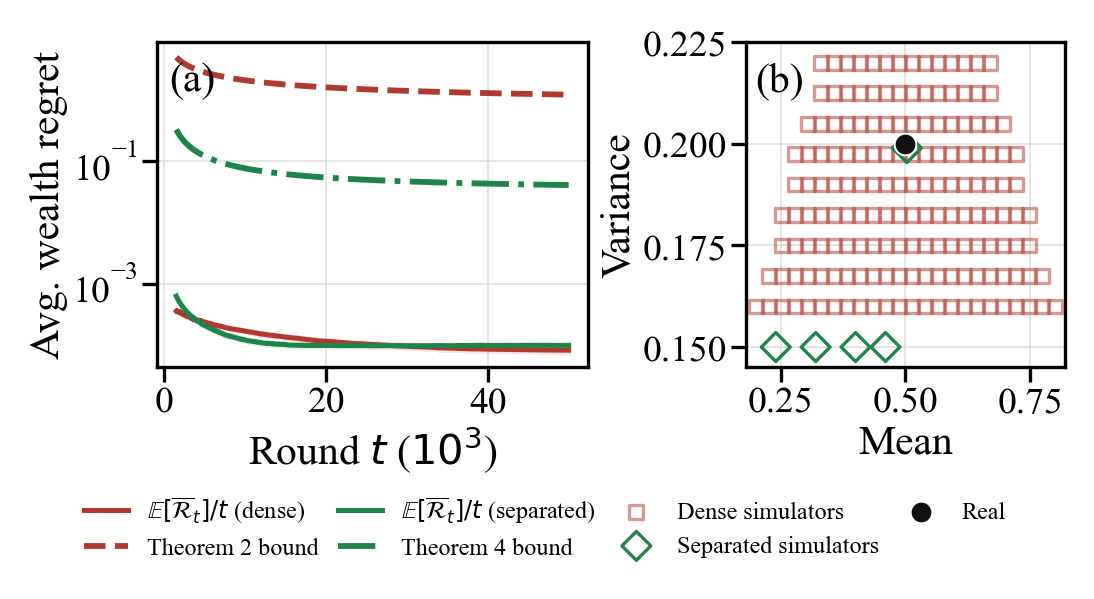

In [5]:
bank_colors = {"Dense bank": "#b03a2e", "Separated bank": "#1e8449"}
plot_floor = 1e-7

fig, axes = plt.subplots(
    1, 2, figsize=(3.5, 1.90), dpi=300,
    gridspec_kw={"width_ratios": [1.15, 0.85]},
)

ax = axes[0]
plot_mask = TIMES >= PLOT_START
plot_times = TIMES[plot_mask] / 1000.0
regret_handles = {}
for bank_name in BANKS:
    mean = RESULTS[bank_name]["mean_regret"][plot_mask]
    half_width = 1.96 * RESULTS[bank_name]["se_regret"][plot_mask]
    regret_handles[bank_name], = ax.plot(
        plot_times,
        np.maximum(mean, plot_floor),
        color=bank_colors[bank_name],
        linewidth=1.2,
    )
    ax.fill_between(
        plot_times,
        np.maximum(mean - half_width, plot_floor),
        np.maximum(mean + half_width, plot_floor),
        color=bank_colors[bank_name],
        alpha=0.12,
    )

theorem_two_handle, = ax.plot(
    plot_times,
    THEOREM_2_BOUND[plot_mask],
    color=bank_colors["Dense bank"],
    linewidth=1.4,
    linestyle="--",
)
theorem_four_handle, = ax.plot(
    plot_times,
    THEOREM_4_BOUND[plot_mask],
    color=bank_colors["Separated bank"],
    linewidth=1.4,
    linestyle="-.",
)
ax.set_xlabel(r"Round $t$ ($10^3$)", labelpad=1)
ax.set_ylabel("Avg. wealth regret", labelpad=1)
ax.set_yscale("log")
ax.grid(True, which="both", color="#d7d7d7", linewidth=0.4, alpha=0.75)
ax.tick_params(axis="both", pad=1)
ax.text(0.03, 0.94, "(a)", transform=ax.transAxes, ha="left", va="top")

ax = axes[1]
geometry_handles = []
for bank_name, marker in [("Dense bank", "s"), ("Separated bank", "D")]:
    means, variances = bank_arrays(BANKS[bank_name])
    geometry_handles.append(
        ax.scatter(
            means,
            variances,
            s=11 if bank_name == "Dense bank" else 24,
            marker=marker,
            facecolors="none",
            edgecolors=bank_colors[bank_name],
            linewidths=0.8,
            alpha=0.52 if bank_name == "Dense bank" else 1.0,
            zorder=3,
        )
    )
real_handle = ax.scatter(
    [MU_STAR],
    [SIGMA2],
    s=27,
    marker="o",
    color="#111111",
    edgecolors="white",
    linewidths=0.45,
    zorder=4,
)
ax.set_xlabel("Mean", labelpad=1)
ax.set_ylabel("Variance", labelpad=1)
ax.set_xlim(0.18, 0.82)
ax.set_ylim(0.145, 0.225)
ax.grid(True, color="#d7d7d7", linewidth=0.4, alpha=0.75)
ax.tick_params(axis="both", pad=1)
ax.text(0.03, 0.94, "(b)", transform=ax.transAxes, ha="left", va="top")

fig.legend(
    [
        regret_handles["Dense bank"],
        theorem_two_handle,
        regret_handles["Separated bank"],
        theorem_four_handle,
        *geometry_handles,
        real_handle,
    ],
    [
        r"$\mathbb{E}[\overline{\mathcal{R}}_t]/t$ (dense)",
        "Theorem 2 bound",
        r"$\mathbb{E}[\overline{\mathcal{R}}_t]/t$ (separated)",
        "Theorem 4 bound",
        "Dense simulators",
        "Separated simulators",
        "Real",
    ],
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=5.8,
    bbox_to_anchor=(0.5, 0.025),
    handlelength=1.8,
    columnspacing=0.8,
)
fig.subplots_adjust(left=0.13, right=0.995, bottom=0.40, top=0.97, wspace=0.42)
fig.savefig(DATA_DIR / "theory_demo.png", dpi=300)
plt.show()
